# Projet de Deep Learning (Professeur Hugo Inzirillo)

Louis Kamaie

## Paper "Stock Price Volatility Prediction with Long Short Term Memory Neural Networks, Jason C. Sullivan (Stanford University)

Il s'agit ici d'un problème de prédiction de la volatilité du prix d'actions appartenant au marché US.

Pour ce faire, sera un employé un réseau de neurones récurrent à mémoire court-terme et long-terme (LSTM) qui appartient à la famille des réseaux de neurones récurrents (RNN).

L'idée principale de l'application du LSTM dans le cas de la prédiction de la volatilité est que ce type de réseau est particulièrement adapté pour pour les séries temporelles contenant des périodes fluctuantes entre différents évènements (de forte volatilité par exemple). En effet, ce type de réseau a la capacité de conserver en mémoire l'occurence de tels évènements.


### Description des données

Le jeu de données provient du site Kaggle (Huge Stock Market Dataset) et contient près de 18 années de données daily pour des actions indiviuelles et des ETFs : Open, High, Low, Close, Volume, and Open Interest.

Suivant le process du chercheur, seront uniquement conservées les 1000 actions inviduelles les plus échangées en termes de volume sur une période 2013-2018 et les features (X) obtenues ainsi :

- Log return
- Log volume change
- Log trading trading range : High vs Low
- Previous 30-day volatility
- Previous 10-day volatility
- Garch forward-looking 10-day volatility

A noter que pour obtenir la volatilité 10-day Garch, le processus consistant à estimer un modèle à chaque pas de temps pour chaque stock a été conséquent en termes computationnel. En effet, il a fallu laissé tourner le code pendant plus de 12 heures afin d'obtenir les prédictions pour les 1000 stocks.

Par ailleurs, pour éviter certains outliers dû à une erreur de prédiciton (exemple su stock "nke"), j'ai implémenté une cotnrainte au niveau de la prédiction (inférieure à 0.01). De plus, pour certains stocks, des problèmes sont appararus (nan, inf value) lors de la prédiction et ne sont pas inclus.

Ainsi, le jeu de données final contient 843 stocks avec plus d'un million de prix daily.

La variable cible correspond à la volatilité forward-looking 10-day du prix (y).



### Plan

Les étapes 1 et 2 sont à passées car le data set final a déjà été obtenu après les retraitements mentionnés et qui prennent énormément de temps. Ainsi, passer directement à l'étape 3.

- 1) (à passer) Collection des données (fichier zip) & Création X et y

- 2) (à passer) Ajout des prédictions du modèle GARCH

- 3) Application LSTMs à un stock

- 4) Application LSTMs aux 100 premiers stocks

- 5) Résultats et Conlusions


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

import warnings
warnings.filterwarnings('ignore')

from arch import arch_model
from arch.__future__ import reindexing
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import zipfile
import csv
import io

from sklearn.model_selection import train_test_split


# 1) (à passer) Collection des données (fichier zip) & Création X et y

In [2]:
path = r"C:\Users\louis\Desktop\Deep Learning\archive.zip"

In [1]:
def download_and_prepare_data_from_zip(path):

    with zipfile.ZipFile(path, "r") as f:
        
        all_dfs = []
        for name in f.namelist():
            
            with f.open(name) as a:

                if "ETFs" in name:
                    print("Not include because ETF (focusing on Single Stock only here.)")
                    continue

                elif "Stocks" in name:

                    try:
                        # Date
                        df = df[(df.Date >= '2013-01') & (df.Date < '2018-01')]
                        
                        # X
                        df = pd.read_csv(a, encoding='utf8', sep=",")
                        df['log_close_ret'] = np.log(df.Close) - np.log(df.Close.shift(1))
                        df['log_volume_change'] = np.log(df.Volume) - np.log(df.Volume.shift(1))
                        df['log_trading_range'] = np.log(df.High) - np.log(df.Low.shift(1))
                        df['previous_30_volatilities'] = df["log_close_ret"].rolling(30).std()*(252**0.5)
                        df['previous_10_volatilities'] = df["log_close_ret"].rolling(10).std()*(252**0.5)
                                            
                        # y
                        # compute FORWARD 10-DAY VOL : inverse rolling, compute, reinverse rolling
                        daily_vol = df["log_close_ret"].rolling(2).std() * (252*0.5)
                        forward_10_vol = daily_vol[::-1].rolling(10).mean()[::-1]
                        forward_10_vol = pd.DataFrame(forward_10_vol)
                        forward_10_vol.columns = ["next_10_vol"]
                        df = pd.merge(df,forward_10_vol, left_index=True, right_index=True)
                        df = df.dropna()
                        
                        # Ticker identification
                        if len(name) == 26:
                            ticker = name[12:19]
                        elif len(name) == 25:
                            ticker = name[12:18]
                        elif len(name) == 24:
                            ticker = name[12:17]
                        elif len(name) == 23:
                            ticker = name[12:16]
                        elif len(name) == 22:
                            ticker = name[12:15]
                        elif len(name) == 21:
                            ticker = name[12:14]
                        else:
                            ticker = name[12:13]

                        df["Ticker"] = ticker

                        print(ticker, name)


                    except:
                        print("Text file does not contain necessary data or columns.")

                    all_dfs.append(df)
    
    all_dfs = pd.concat(all_dfs)
    
    # Select 1000 most traded stocks (based on volume)
    mean_per_ticker = all_dfs.groupby('Ticker')['Volume'].mean()
    mean_per_ticker = mean_per_ticker.sort_values(ascending=False)
    retained_tickers = list(mean_per_ticker[:1000].index)
    all_dfs = all_dfs[all_dfs["Ticker"].isin(retained_tickers)]

    return all_dfs

all_dfs = download_and_prepare_data_from_zip(path)
all_dfs

# 2) (à passer) Ajout des prédictions du modèle GARCH

In [ ]:
# Apply Garch sprecification on each 1000 retained stocks
# Goal : obtaind 10 days Garch volatility (per stock)
def garch_for_each_retained_stock(df_stock):
    
    rolling_predictions = []
    
    # GARCH in forward mode : using all previous days
    for i in range(len(df_stock)):

        data_used_for_predictions = df_stock['log_close_ret'][0:i+1]

        print(len(data_used_for_predictions))

        try:
            model = arch_model(data_used_for_predictions, p=15, q=15)
            model_fit = model.fit(disp='off')
        except:
            continue

        # horizon 10 : predict the next 10 days volatilities
        pred = model_fit.forecast(horizon=10)
        var_pred = pred.variance.values[-1,:].mean()
        
        # constraint for optimization reason
        if var_pred < 0.01:
            rolling_predictions.append(var_pred)
        else:
            continue
    
    return rolling_predictions


In [ ]:
final_all_dfs = []

stocks_list = all_dfs["Ticker"].unique()

# Iterate all stocks
for stock in stocks_list:
    
    print(stock)
    
    # loop over each stock
    df_stock = all_dfs[all_dfs.Ticker == stock]
    
    # get GARCH series with 10 days as horizon
    try:
        garch_series = garch_for_each_retained_stock(df_stock) 
        garch_df = pd.DataFrame(garch_series)
        garch_df.columns = ["garch"]
    
        # add into df_stock
        df_stock = df_stock.reset_index()
        df = pd.merge(df_stock, garch_df, left_index=True, right_index=True)

        final_all_dfs.append(df)
        
    # If error occurs when running Garch
    except:
        continue


# 3) Application LSTMs à un stock

In [50]:
# Import full df
df_final = pd.read_csv(r"C:\Users\louis\Desktop\Deep Learning\FINAL_DATASET.csv")

In [51]:
# FIGURE function
def graph(df, title):
    plt.figure(figsize=(10,4))
    plt.plot(df)
    plt.title(title)
    plt.show()

In [52]:
# Select a single stock
df = df_final[df_final["Ticker"]=="amzn"]

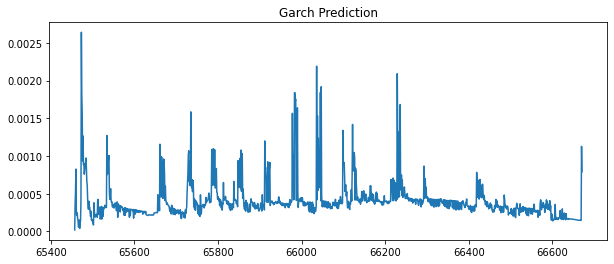

In [53]:
graph(df["garch"], "Garch Prediction")

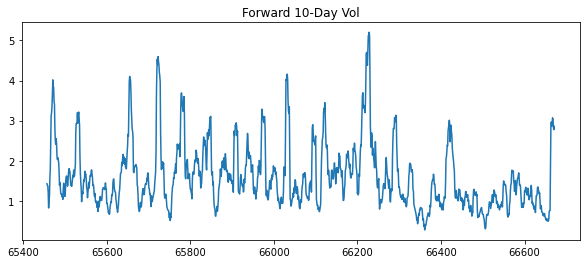

In [54]:
graph(df["next_10_vol"], "Forward 10-Day Vol")

In [190]:
# df engineering function

def get_train_test_dfs(df):

    features = ["log_close_ret","log_volume_change","log_trading_range","previous_30_volatilities","previous_10_volatilities","garch"]

    X = df.loc[:, features]
    y = df.loc[:, ["next_10_vol"]]
    
    # 80 / 20 split
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, train_size = .80)

    X_train = torch.from_numpy(np.array(X_train)).type(torch.FloatTensor)
    y_train = torch.from_numpy(np.array(y_train)).type(torch.FloatTensor)

    X_test = torch.from_numpy(np.array(X_test)).type(torch.FloatTensor)
    y_test = torch.from_numpy(np.array(y_test)).type(torch.FloatTensor)

    X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))
    
    return X_train, X_test, y_train, y_test


In [191]:
X_train, X_test, y_train, y_test = get_train_test_dfs(df)
X_train.shape

torch.Size([972, 1, 6])

## Modèle LSTM 1 : baseline model

- inout size = 6 features
- hidden size = 5 hidden units
- num layers = 1 single LSTM layer
- output size = 1 unit output
- epochs = 5000
- optimize = Adam
- learning rate = 0.01

1) Instantiation du Modèle

2) Application du Modèle : get MSE

Par soucis de simplicité, j'ai fait le choix de me concentrer uniquement sur la métrique d'erreur MSE (Means Squarred Error) pour comparer les performances.

La batch size de 30 points de données ne sera pas utilisée car le code prend trop de temps à tourner. Il s'agira donc à chaque epoch d'itérer l'ensemble du jeu de données. Cela peut potentiellement impacter le résultats du modèle qui aura tendance à overfitter et aura donc des difficultés à généraliser le résultat sur un nouveau jeu de données.

In [23]:
class LSTM(nn.Module):
    
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTM, self).__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.output_dim = output_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first = True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, X):
        h0 = torch.zeros(self.num_layers, X.size(0), self.hidden_dim).requires_grad_()
        c0 = torch.zeros(self.num_layers, X.size(0), self.hidden_dim).requires_grad_()
        out, (hn,cn) = self.lstm(X, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])
        return out


In [12]:
model = LSTM(6,5,1,1)
optimiser = torch.optim.Adam(model.parameters(), lr=0.01)

print(model)

for i in range(len(list(model.parameters()))):
    print(list(model.parameters())[i].size())

LSTM(
  (lstm): LSTM(6, 5, batch_first=True)
  (fc): Linear(in_features=5, out_features=1, bias=True)
)
torch.Size([20, 6])
torch.Size([20, 5])
torch.Size([20])
torch.Size([20])
torch.Size([1, 5])
torch.Size([1])


In [13]:
def get_MSE_single_stock(model, X_train,y_train,X_test,y_test,epochs):
    
    hist = np.zeros(epochs)
    loss_fn = torch.nn.MSELoss()
    
    # TRAIN
    for t in range(epochs):
        model.train()
        optimiser.zero_grad()
        y_pred_train = model(X_train)
        loss = loss_fn(y_pred_train, y_train)
        
        #if t%10==0 and t!=0:
            #print( "Epoch",t,"MSE:", loss.item())
            
        hist[t] = loss.item()
        loss.backward()
        optimiser.step()
        
    mse_train = hist[-1]
    
    
    # TEST
    y_pred_test = model(X_test)
    mse_test = loss_fn(y_pred_test, y_test).item()
    
    # PLOT
    plt.figure(figsize=(10,6))
    plt.plot(y_test.detach().numpy(), label='Actuall Data')
    plt.plot(y_pred_test.detach().numpy(), label='Predicted Data')
    plt.title('Time-Series Prediction')
    plt.legend()
    plt.show()

    return mse_train, mse_test
    

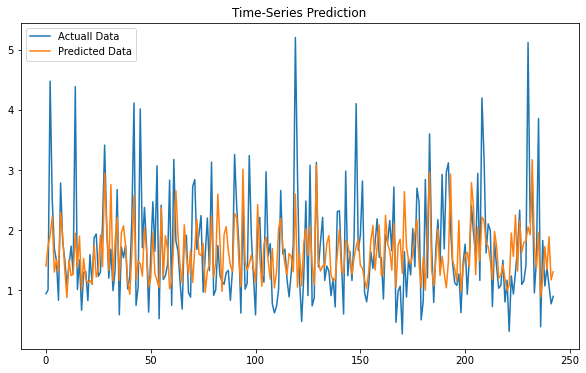

MSE train 0.40862634778022766
MSE test 0.5775517225265503


In [14]:
mse = get_MSE_single_stock(model, X_train, y_train, X_test, y_test, 5000)
print('MSE train', mse[0])
print('MSE test', mse[1])

## Modèle LSTM 2 : extended model

- inout size = 6 features
- hidden size = 5 hidden units
- num layers = 10 single LSTM layer
- dropout = 10%
- output size = 1 unit output
- epochs = 5000
- optimize = Adam
- learning rate = 0.01

1) Instantiation du Modèle

2) Application du Modèle : get MSE

Par soucis de simplicité, j'ai fait le choix de me concentrer uniquement sur la métrique d'erreur MSE (Means Squarred Error) pour comparer les performances.

Le nombre de hidden layers et de LSTM layers a été réduit à 5 et 10 respectivement pour des raisons de temps de calcul.

Par ailleurs, l'application du layer GRU n'a pas été réalisée (voir ci-dessous). Après plusieurs recherches, je n'ai pas réussi à trouver une méthode satisfaisante pour l'implémenter. En effet, le GRU semble être un modèle à part entière tel que le LSTM, ainsi l'ajouter au LSTM dans un framework général a paru complexe.

Il est à noter que l'auteur du papier utilise Keras et non PyTorch pour l'implémentation, ce qui apparaît à priori plus aisé :)

In [204]:
class LSTM_optimized(nn.Module):
    
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        
        super(LSTM_optimized, self).__init__()
        
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.output_dim = output_dim
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first = True)     
        self.dropout1 = nn.Dropout(0.1)
        self.linear1 = nn.Linear(hidden_dim, output_dim)
        
#         self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
#         self.dropout2 = nn.Dropout(0.1)
#         self.linear2 = nn.Linear(hidden_dim, output_dim)
        
        self.activation = nn.ReLU()
        

    def forward(self, X):
        
        h0 = torch.zeros(self.num_layers, X.size(0), self.hidden_dim).requires_grad_()
        c0 = torch.zeros(self.num_layers, X.size(0), self.hidden_dim).requires_grad_()
        
        # LSTM
        out, (hn,cn) = self.lstm(X, (h0.detach(), c0.detach()))
        # dropout 10%
        out = self.dropout1(out)
        # relu activation
        out_1 = self.activation(self.linear1(out[:, -1, :]))
        
#         # GRU
#         out, (hn,cn) = self.gru(X, (h0.detach(), c0.detach()))
#         # dropout 10%
#         out = self.dropout2(out)
#         # relu activation
#         out_2 = self.activation(self.linear2(out[:, -1, :]))
        
        return out_1


In [205]:
# model setup
model = LSTM_optimized(6,5,10,1)
optimiser = torch.optim.Adam(model.parameters(), lr=0.01)

print(model)

for i in range(len(list(model.parameters()))):
    print(list(model.parameters())[i].size())

LSTM_optimized(
  (lstm): LSTM(6, 5, num_layers=10, batch_first=True)
  (dropout1): Dropout(p=0.1, inplace=False)
  (linear1): Linear(in_features=5, out_features=1, bias=True)
  (activation): ReLU()
)
torch.Size([20, 6])
torch.Size([20, 5])
torch.Size([20])
torch.Size([20])
torch.Size([20, 5])
torch.Size([20, 5])
torch.Size([20])
torch.Size([20])
torch.Size([20, 5])
torch.Size([20, 5])
torch.Size([20])
torch.Size([20])
torch.Size([20, 5])
torch.Size([20, 5])
torch.Size([20])
torch.Size([20])
torch.Size([20, 5])
torch.Size([20, 5])
torch.Size([20])
torch.Size([20])
torch.Size([20, 5])
torch.Size([20, 5])
torch.Size([20])
torch.Size([20])
torch.Size([20, 5])
torch.Size([20, 5])
torch.Size([20])
torch.Size([20])
torch.Size([20, 5])
torch.Size([20, 5])
torch.Size([20])
torch.Size([20])
torch.Size([20, 5])
torch.Size([20, 5])
torch.Size([20])
torch.Size([20])
torch.Size([20, 5])
torch.Size([20, 5])
torch.Size([20])
torch.Size([20])
torch.Size([1, 5])
torch.Size([1])


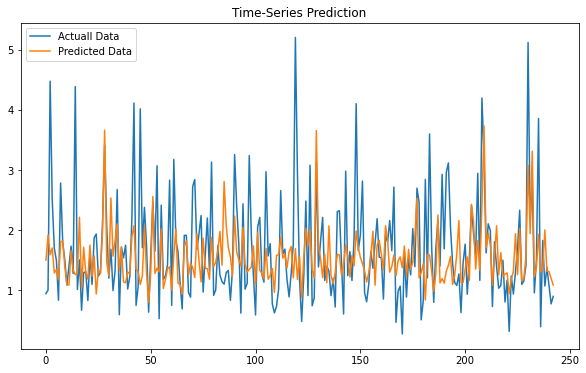

MSE train 0.4045955240726471
MSE test 0.6414801478385925


In [206]:
mse = get_MSE_single_stock(model, X_train, y_train, X_test, y_test, 5000)
print('MSE train', mse[0])
print('MSE test', mse[1])

# 4) Application LSTMs aux 100 premiers stocks

Pour des raisons de temps de calcul, j'ai appliqué les modèles aux 100 premiers stocks de l'échantillon de 842 stocks.

In [41]:
list_stocks = df_final["Ticker"].unique()[:100]
list_stocks

array(['a', 'aa', 'aaba', 'aapl', 'aaxn', 'abb', 'abc', 'abev', 'abt',
       'abx', 'acad', 'achn', 'acn', 'adbe', 'adi', 'adm', 'adp', 'adsk',
       'aee', 'aeg', 'aem', 'aeo', 'aep', 'aer', 'aes', 'aet', 'afl',
       'afsi', 'ag', 'agn', 'agnc', 'ago', 'aig', 'ainv', 'aiv', 'akam',
       'akrx', 'aks', 'alb', 'alk', 'all', 'alsn', 'alxn', 'amat', 'amba',
       'amd', 'ame', 'amgn', 'amkr', 'amp', 'amrn', 'amt', 'amtd', 'amx',
       'amzn', 'andv', 'anf', 'anh', 'antm', 'aobc', 'aon', 'aos', 'apa',
       'apc', 'apd', 'aph', 'apo', 'arcc', 'arrs', 'arry', 'arwr', 'ash',
       'asna', 'ati', 'atvi', 'au', 'auo', 'auy', 'aveo', 'avgo', 'avp',
       'axas', 'axl', 'axp', 'azn', 'ba', 'bac', 'bax', 'bb', 'bbby',
       'bbd', 'bbg', 'bbl', 'bbt', 'bbva', 'bby', 'bcrx', 'bcs', 'bdn',
       'ben'], dtype=object)

## Modèle LSTM 1 : baseline model

In [42]:
# model setup
model = LSTM(6,5,1,1)
optimiser = torch.optim.Adam(model.parameters(), lr=0.01)

print(model)

for i in range(len(list(model.parameters()))):
    print(list(model.parameters())[i].size())

LSTM(
  (lstm): LSTM(6, 5, batch_first=True)
  (fc): Linear(in_features=5, out_features=1, bias=True)
)
torch.Size([20, 6])
torch.Size([20, 5])
torch.Size([20])
torch.Size([20])
torch.Size([1, 5])
torch.Size([1])


In [43]:
def get_MSE_all_stocks(model, X_train,y_train,X_test,y_test,epochs):
    
    hist = np.zeros(epochs)
    loss_fn = torch.nn.MSELoss()
    
    # TRAIN
    for t in range(epochs):
        model.train()
        optimiser.zero_grad()
        y_pred_train = model(X_train)
        loss = loss_fn(y_pred_train, y_train)
        
        #if t%10==0 and t!=0:
            #print( "Epoch",t,"MSE:", loss.item())
            
        hist[t] = loss.item()
        loss.backward()
        optimiser.step()
        
    mse_train = hist[-1]
    
    
    # TEST
    y_pred_test = model(X_test)
    mse_test = loss_fn(y_pred_test, y_test).item()
    
    return mse_train, mse_test
    

In [2]:
mse_train = []
mse_test = []

for stock in list_stocks:
    
    print(stock)
    
    df_stock = df_final[df_final["Ticker"]==stock]
    
    X_train, X_test, y_train, y_test = get_train_test_dfs(df_stock)
    
    mse = mse = get_MSE_all_stocks(model, X_train, y_train, X_test, y_test, 5000)
    
    mse_train.append(mse[0])
    mse_test.append(mse[1])
    

In [45]:
print("Total train MSE for 100 first stocks :", sum(mse_train))
print("Total test MSE for 100 first stocks :", sum(mse_test))

Total train MSE for 100 first stocks : 74.29559732973576
Total test MSE for 100 first stocks : 106.47012621164322


## Modèle LSTM 2 : extended model

In [207]:
# model setup
model = LSTM_optimized(6,5,10,1)
optimiser = torch.optim.Adam(model.parameters(), lr=0.01)

print(model)

for i in range(len(list(model.parameters()))):
    print(list(model.parameters())[i].size())

LSTM_optimized(
  (lstm): LSTM(6, 5, num_layers=10, batch_first=True)
  (dropout1): Dropout(p=0.1, inplace=False)
  (linear1): Linear(in_features=5, out_features=1, bias=True)
  (activation): ReLU()
)
torch.Size([20, 6])
torch.Size([20, 5])
torch.Size([20])
torch.Size([20])
torch.Size([20, 5])
torch.Size([20, 5])
torch.Size([20])
torch.Size([20])
torch.Size([20, 5])
torch.Size([20, 5])
torch.Size([20])
torch.Size([20])
torch.Size([20, 5])
torch.Size([20, 5])
torch.Size([20])
torch.Size([20])
torch.Size([20, 5])
torch.Size([20, 5])
torch.Size([20])
torch.Size([20])
torch.Size([20, 5])
torch.Size([20, 5])
torch.Size([20])
torch.Size([20])
torch.Size([20, 5])
torch.Size([20, 5])
torch.Size([20])
torch.Size([20])
torch.Size([20, 5])
torch.Size([20, 5])
torch.Size([20])
torch.Size([20])
torch.Size([20, 5])
torch.Size([20, 5])
torch.Size([20])
torch.Size([20])
torch.Size([20, 5])
torch.Size([20, 5])
torch.Size([20])
torch.Size([20])
torch.Size([1, 5])
torch.Size([1])


In [3]:
mse_train = []
mse_test = []

for stock in list_stocks:
    
    print(stock)
    
    df_stock = df_final[df_final["Ticker"]==stock]
    
    X_train, X_test, y_train, y_test = get_train_test_dfs(df_stock)
    
    mse = mse = get_MSE_all_stocks(model, X_train, y_train, X_test, y_test, 5000)
    
    mse_train.append(mse[0])
    mse_test.append(mse[1])
    

In [209]:
print("Total train MSE for 100 first stocks :", sum(mse_train))
print("Total test MSE for 100 first stocks :", sum(mse_test))

Total train MSE for 100 first stocks : 115.68571017682552
Total test MSE for 100 first stocks : 127.54865531623363


# 5) Résultats et Conclusions

Lorsque l'on considère les résultats obtenus avec les 100 premiers stocks, la MSE du dataset de train apparaît moins élevée que celle du dataset de test que ce soit pour le modèle de base ou le modèle optimisé. Ce qui apparaît logique avec un nombre de données plus conséquent. Cependant, les résultats sur les datasets de test apparaissent tout de même pertinent.
Ce résultat est en ligne avec celui de l'auteur.

Lorsque l'on compare le modèle de base au modèle optimisé. Le modèle de base apparaît supérieur. Ce qui laisse supposé que l'optimisation que l'on a souhaité apporter au modèle n'est pas optimale vis-à-vis du jeu de données global.
Ce résultat diverge par rapport à l'auteur dont le modèle optimisé performe mieux.

Une fois cette anlayse dressée, il s'agit de rappeler qu'ici je n'ai pas utlisé les 1000 stocks comme l'auteur l'a fait et que certaines fonctionnalités (batch size, modèle GRU, nombre de layers du LSTM optimisé) n'ont pas été implementées.
Il faut rappeler que l'auteur utilise Keras.

A travers cette étude, j'ai pu voir à quel point la librairie pytorch permet une grande flexibilité dans le niveau d'implémentation du réseau de neurones avec un niveau de détail très élevé.
J'ai également pu développer mes compétences en Deep Learning, en particulier sur le modèle LSTM et son utilité dans des problématiques de prédiction de la volatilité.
